# 02 — Taxonomia de Intenções (Curadobia)

**Objetivo**  
Transformar o dataset limpo do Notebook 01 em um conjunto **rotulado por intenções**, combinando:
1) **Taxonomia** (rótulos e definições)  
2) **Regras (regex)** para *weak labeling* com **desempate por prioridade**  
3) **Baselines de ML** (TF-IDF + modelos lineares) para validar **separabilidade**  
4) **Superfície p/ anotação humana** (amostras incertas) e **artefatos** para uso futuro

**Para quem**  
- **Anotadores**: referência clara de escopo por intenção e desempate.  
- **Analistas/Dev**: regras, prioridade, métricas e checklist de saídas.

**Entradas**  
- `mensagens_unificadas_limpo.csv` (export do Notebook 01)

**Saídas**  
- `taxonomia_intencoes.json` (definições + prioridade + meta)  
- `regras_regex_intencoes.json`  
- `mensagens_rotuladas_fracas.csv`  
- `amostra_para_anotacao.csv` (pool p/ validação humana)  
- `vetorizer.joblib`, `modelo_baseline.joblib`, `modelo_linear_svc.joblib`, `modelo_linear_svc_calibrado.joblib`  
- Relatórios/figuras: distribuição, matriz de confusão, top termos por classe, scoreboard de baselines etc.

**Sumário rápido**  
A. Setup & Entradas → B. Taxonomia + Guia → C. Regras/Regex → D. Rotulagem fraca →  
E. Distribuições/Qualidade → F. Baselines (comparativo + calibrado) → G. Superfície de Anotação → H. Exports & Checklist


In [4]:
# CÉLULA 2 — Setup (VSCode), Paths e Auto-instalação de pacotes faltantes

import sys, subprocess, importlib, os
from pathlib import Path

# ===== Descoberta do ROOT do repo (compatível com o NB00) =====
def resolve_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "code").exists() and (
            (p / "requirements.txt").exists() or (p / "README.md").exists() or (p / ".git").exists()
        ):
            return p
    return start

CWD = Path.cwd()
ROOT = resolve_repo_root(CWD)
print("ROOT:", ROOT)

# ===== Onde ler a saída do NB01 e onde gravar a saída do NB02 =====
# Preferência: artefatos do NB01 em code/notebooks/outputs/
NB01_OUT_CANDIDATES = [
    ROOT / "code" / "notebooks" / "outputs" / "mensagens_unificadas_limpo.csv",
    ROOT / "code" / "notebooks" / "mensagens_unificadas_limpo.csv",
    Path("/mnt/data/notebooks/outputs/mensagens_unificadas_limpo.csv"),
    Path("/mnt/data/mensagens_unificadas_limpo.csv"),
]
def pick_first_exists(paths):
    for p in paths:
        if p.exists():
            return p
    return None

INFILE = pick_first_exists(NB01_OUT_CANDIDATES)
if INFILE is None:
    raise FileNotFoundError(
        "Não encontrei 'mensagens_unificadas_limpo.csv'. "
        "Execute o Notebook 01 e confirme se foi exportado para 'code/notebooks/outputs/'."
    )

# Saída deste Notebook 02
OUTDIR = ROOT / "code" / "notebooks" / "outputs" / "notebook02"
OUTDIR.mkdir(parents=True, exist_ok=True)
print("✓ Arquivo de entrada:", INFILE)
print("✓ Pasta de saída    :", OUTDIR)

# ===== Auto-instalação (apenas se faltar) =====
# Mapeia "package" (pip) → "module" (import). Isso corrige o erro do import de scikit-learn.
PKGS = [
    {"package": "pandas",          "module": "pandas"},
    {"package": "numpy",           "module": "numpy"},
    {"package": "scikit-learn",    "module": "sklearn"},
    {"package": "joblib",          "module": "joblib"},
    {"package": "ftfy",            "module": "ftfy"},
    {"package": "unidecode",       "module": "unidecode"},
    {"package": "matplotlib",      "module": "matplotlib"},
    {"package": "seaborn",         "module": "seaborn"},
]

def ensure_pkg(package: str, module: str):
    try:
        return importlib.import_module(module)
    except ModuleNotFoundError:
        print(f"• Instalando '{package}'…")
        # usa o mesmo Python do kernel
        subprocess.run([sys.executable, "-m", "pip", "install", package], check=True)
        return importlib.import_module(module)

for item in PKGS:
    ensure_pkg(item["package"], item["module"])

print("✓ Dependências ok (via requirements e/ou auto-instalação).")


ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
✓ Arquivo de entrada: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\mensagens_unificadas_limpo.csv
✓ Pasta de saída    : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02
✓ Dependências ok (via requirements e/ou auto-instalação).


In [ ]:
# CÉLULA 2 — Setup (VSCode), Paths e Auto-instalação de pacotes faltantes

import sys, subprocess, importlib, os
from pathlib import Path

# ===== Descoberta do ROOT do repo (compatível com o NB00) =====
def resolve_repo_root(start: Path) -> Path:
    """Busca o diretório raiz do repositório subindo a árvore de diretórios."""
    for p in [start, *start.parents]:
        # Define o ROOT se encontrar a pasta 'code' e um arquivo de repositório (e.g., requirements.txt).
        if (p / "code").exists() and (
            (p / "requirements.txt").exists() or (p / "README.md").exists() or (p / ".git").exists()
        ):
            return p
    return start

CWD = Path.cwd()
ROOT = resolve_repo_root(CWD)
print("ROOT:", ROOT)

# ===== Onde ler a saída do NB01 e onde gravar a saída do NB02 =====
# Define caminhos potenciais onde o arquivo de saída do Notebook 01 pode estar.
NB01_OUT_CANDIDATES = [
    ROOT / "code" / "notebooks" / "outputs" / "mensagens_unificadas_limpo.csv",
    ROOT / "code" / "notebooks" / "mensagens_unificadas_limpo.csv",
    Path("/mnt/data/notebooks/outputs/mensagens_unificadas_limpo.csv"),
    Path("/mnt/data/mensagens_unificadas_limpo.csv"),
]
def pick_first_exists(paths):
    """Retorna o primeiro caminho que existe na lista."""
    for p in paths:
        if p.exists():
            return p
    return None

# Tenta encontrar o arquivo de entrada e levanta um erro se não for localizado.
INFILE = pick_first_exists(NB01_OUT_CANDIDATES)
if INFILE is None:
    raise FileNotFoundError(
        "Não encontrei 'mensagens_unificadas_limpo.csv'. "
        "Execute o Notebook 01 e confirme se foi exportado para 'code/notebooks/outputs/'."
    )

# Define e cria o diretório de saída para este Notebook 02.
OUTDIR = ROOT / "code" / "notebooks" / "outputs" / "notebook02"
OUTDIR.mkdir(parents=True, exist_ok=True)
print("✓ Arquivo de entrada:", INFILE)
print("✓ Pasta de saída    :", OUTDIR)

# ===== Auto-instalação (apenas se faltar) =====
# Lista de pacotes a serem verificados e instalados.
PKGS = [
    {"package": "pandas", "module": "pandas"},
    {"package": "numpy", "module": "numpy"},
    {"package": "scikit-learn", "module": "sklearn"},
    {"package": "joblib", "module": "joblib"},
    {"package": "ftfy", "module": "ftfy"},
    {"package": "unidecode", "module": "unidecode"},
    {"package": "matplotlib", "module": "matplotlib"},
    {"package": "seaborn", "module": "seaborn"},
]

def ensure_pkg(package: str, module: str):
    """Verifica se um módulo existe e o instala se estiver faltando."""
    try:
        return importlib.import_module(module)
    except ModuleNotFoundError:
        print(f"• Instalando '{package}'…")
        # Executa o comando pip install usando o Python atual.
        subprocess.run([sys.executable, "-m", "pip", "install", package], check=True)
        return importlib.import_module(module)

# Itera sobre a lista de pacotes e garante a instalação.
for item in PKGS:
    ensure_pkg(item["package"], item["module"])

print("✓ Dependências ok (via requirements e/ou auto-instalação).")

ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
✓ Arquivo de entrada: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\mensagens_unificadas_limpo.csv
✓ Pasta de saída    : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02
✓ Dependências ok (via requirements e/ou auto-instalação).


In [ ]:
# CÉLULA 3 — Imports, Aparência e Semente

import re, json, unicodedata, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from unidecode import unidecode

import matplotlib.pyplot as plt
import seaborn as sns

# ML
# Importa módulos para divisão de dados e validação.
from sklearn.model_selection import StratifiedKFold
# Importa vetorizadores para conversão de texto em formato numérico.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
# Importa modelos de classificação.
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
# Importa o wrapper para calibragem de probabilidade.
from sklearn.calibration import CalibratedClassifierCV
# Importa métricas e ferramentas de avaliação.
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score
)
# Importa codificador de rótulos.
from sklearn.preprocessing import LabelEncoder
# Importa funções para persistência (salvar/carregar) de modelos.
from joblib import dump, load

# Ignora avisos (warnings) para manter o notebook limpo.
warnings.filterwarnings("ignore")
# Define a semente aleatória para reprodutibilidade.
np.random.seed(42)

# Configura o tema visual dos gráficos e o pandas para exibir mais texto.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [ ]:
# CÉLULA 4 — Utilitários de Texto

def normalize_text(s: str) -> str:
    """Corrige encoding (ftfy), remove NUL e compacta espaços."""
    if not isinstance(s, str):
        # Garante que a entrada é uma string, retornando vazio se não for.
        return ""
    # Substitui o caractere nulo por um espaço.
    s = s.replace("\x00", " ")
    try:
        # Tenta importar e usar a biblioteca 'ftfy' para corrigir problemas de codificação.
        import ftfy
        s = ftfy.fix_text(s)
    except Exception:
        pass
    # Substitui múltiplos espaços por um único e remove espaços nas extremidades.
    return re.sub(r"\s+", " ", s).strip()

def basic_clean(s: str) -> str:
    """Limpeza leve para ML (lower, sem URLs/menções, pouca pontuação)."""
    # Normaliza e converte o texto para minúsculas.
    s = normalize_text(s).lower()
    # Remove URLs (HTTP/WWW).
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    # Remove menções (@user) e hashtags (#tag).
    s = re.sub(r"[@#]\w+", " ", s)
    # Remove a maioria da pontuação, mantendo apenas caracteres de palavra e acentos.
    s = re.sub(r"[^\w\sáéíóúâêôãõç]", " ", s)
    # Compacta espaços resultantes da remoção de pontuação.
    return re.sub(r"\s+", " ", s).strip()

def norm_match(s: str) -> str:
    """ASCII + lower (para regex robusta, insensível a acentos)."""
    # Normaliza o texto, remove acentos (unidecode) e converte para minúsculas.
    return unidecode(normalize_text(s)).lower()

In [8]:
# CÉLULA 5 — Carrega dataset limpo (entrada NB01) e foca no lado=cliente

df = pd.read_csv(INFILE)
for c in ["ts","autor","texto","origem","lado"]:
    if c not in df.columns: 
        df[c] = pd.NA

df["texto"] = df["texto"].astype(str).map(normalize_text)
df["lado"]  = df["lado"].fillna("cliente")

df_cli = df[df["lado"].eq("cliente")].copy().reset_index(drop=True)

print("Linhas totais (lado=cliente):", len(df_cli))
display(df_cli.head(5))


Linhas totais (lado=cliente): 745


,id,ts,texto,intent,origem,arquivo_origem,is_ruido,fonte,split,is_synth_test,lado,texto_clean,texto_tokens,texto_clean2,flag_tamanho,flag_sugestao,autor
0,6e5173ce406e6d86,NaN,de todo modo agradeco por perguntar,agradecimento,raw,NaN,False,original,train,NaN,cliente,de todo modo agradeco por perguntar,"['todo', 'modo', 'agradeco', 'perguntar']",todo modo agradeco perguntar,False,False,<NA>
1,58c246aeb9ce9f16,NaN,agradeco o feedback,agradecimento,raw,NaN,False,original,train,NaN,cliente,agradeco o feedback,"['agradeco', 'feedback']",agradeco feedback,False,False,<NA>
2,bf5cd3b6d66ca38f,NaN,obg!!,agradecimento,raw,NaN,False,original,train,NaN,cliente,obg,[],NaN,False,False,<NA>
3,7d26ed2bf0bc8bc9,NaN,tem body preto tamanho 40?,buscar_produto_por_categoria,synthetic,NaN,False,synthetic,train,NaN,cliente,tem body preto tamanho 40,"['body', 'preto', 'tamanho']",body preto tamanho,True,False,<NA>
4,f8ddcc6d39326159,NaN,tem vestido verde tamanho 38?,buscar_produto_por_categoria,synthetic,NaN,False,synthetic,train,NaN,cliente,tem vestido verde tamanho 38,"['vestido', 'verde', 'tamanho']",vestido verde tamanho,True,False,<NA>


In [9]:
# CÉLULA 6 — Taxonomia + Prioridade

TAXONOMIA = {
    "saudacao":           "Saudar/iniciar conversa (oi, olá, bom dia, boa tarde, boa noite).",
    "agradecimento":      "Agradecer/elogiar (obrigada, valeu, amei, perfeito).",
    "despedida":          "Encerrar conversa (tchau, até logo/mais).",
    "duvida_tamanho":     "Medidas/numeração/serve-caber/PP–GG/modelagem.",
    "pedido_sugestao":    "Sugestão de looks/combinações/usar com/ideia de.",
    "disponibilidade":    "Estoque/reposição/‘tem?’/tamanho/cor disponível.",
    "preco_pagamento":    "Preço/valor, formas de pagamento (PIX, boleto, cartão, parcelar).",
    "prazo_entrega":      "Prazo/frete/rastreio/‘chega quando’.",
    "troca_devolucao":    "Troca/devolução/defeito/não serviu/tamanho errado.",
    "onde_comprar":       "Como/onde comprar (site, Insta, WhatsApp, link).",
    "cupom_primeira":     "Cupom/código de desconto (especialmente 1ª compra).",
    "erro_plataforma":    "Erro/bug, não consigo pagar/logar, travou etc.",
    "outros":             "Não encaixa em nenhuma das anteriores."
}

PRIORIDADE = [
    "erro_plataforma","troca_devolucao","prazo_entrega","preco_pagamento",
    "cupom_primeira","duvida_tamanho","disponibilidade","pedido_sugestao",
    "onde_comprar","saudacao","agradecimento","despedida","outros"
]

# salva
(OUTDIR / "taxonomia_intencoes.json").write_text(json.dumps(TAXONOMIA, ensure_ascii=False, indent=2), encoding="utf-8")
print("✓ Taxonomia salva:", OUTDIR / "taxonomia_intencoes.json")

pd.DataFrame({"intent": list(TAXONOMIA.keys()),
              "definicao": list(TAXONOMIA.values())})


✓ Taxonomia salva: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\taxonomia_intencoes.json


,intent,definicao
0,saudacao,"Saudar/iniciar conversa (oi, olá, bom dia, boa tarde, boa noite)."
1,agradecimento,"Agradecer/elogiar (obrigada, valeu, amei, perfeito)."
2,despedida,"Encerrar conversa (tchau, até logo/mais)."
3,duvida_tamanho,Medidas/numeração/serve-caber/PP–GG/modelagem.
4,pedido_sugestao,Sugestão de looks/combinações/usar com/ideia de.
5,disponibilidade,Estoque/reposição/‘tem?’/tamanho/cor disponível.
6,preco_pagamento,"Preço/valor, formas de pagamento (PIX, boleto, cartão, parcelar)."
7,prazo_entrega,Prazo/frete/rastreio/‘chega quando’.
8,troca_devolucao,Troca/devolução/defeito/não serviu/tamanho errado.
9,onde_comprar,"Como/onde comprar (site, Insta, WhatsApp, link)."


In [10]:
# CÉLULA 7 — Regras (regex) e dump JSON

REGRAS = {
    "saudacao": [
        r"\boi\b|\bol[aá]\b|bom dia|boa tarde|boa noite|\beai\b|\boii+\b|\boie+?\b",
    ],
    "agradecimento": [
        r"\bobg\b|obrigad[ao]\b|valeu\b|gratid[aã]o|amei\b|perfeit[oa]\b|maravilhos[ao]\b|muito obrigada|mto obg",
        r"\bajudou\b|\bajuda(r|ou)\b|\bbrigad[ao]\b",
    ],
    "despedida": [
        r"\btchau\b|\bat[eé]\s+logo\b|\bat[eé]\s+mais\b|\bat[eé]\b|\babra[cç]os?\b|\babç\b|\bbeijos?\b|\bbjos?\b|\bbjk?s?\b|\bboa noite!?$|\bbom descanso$"
    ],
    "duvida_tamanho": [
        r"\btamanhos?\b|\bnumera[cç][aã]o\b|\bmedid(?:a|as)\b|\bpp\b|\bp\b|\bm\b|\bg\b|\bgg\b|\bxg+?\b",
        r"\bserve(m)?\b|\bfic(?:a|ou)\b|\bcomprimento\b|\blargura\b|\bbusto\b|\bcintura\b|\bquadril\b",
        r"\b36\b|\b38\b|\b40\b|\b42\b|\b44\b|\b46\b|\b48\b",
        r"\b(tabela|guia)\s+de\s+medidas\b|\btabela\s+(pp|p|m|g|gg|xg+)\b",
    ],
    "pedido_sugestao": [
        r"\bsugest\w*\b|\blook(?:s)?\b|\bcombina(?:r|[cç][aã]o|coes|[cç][oõ]es)\b",
        r"\busar com\b|\bmontar\b|\bou?utfit\b|\bideia de\b|\bcom qual\b|\bqual (cal[cç]a|blusa|saia) combina\b",
    ],
    "disponibilidade": [
        r"\btem\b|\bainda tem\b|\best[oó]que\b|\bdispon[ií]vel\b|\breposi(?:c|ç)[aã]o\b|\bquando rep[oó]e\b|\bvolta quando\b",
        r"\btem no tamanho\b|\btem na cor\b|\bpreta\b|\bbranca\b|\bnumera[cç][aã]o\b",
    ],
    "preco_pagamento": [
        r"\bpre[cç]o\b|\bvalor\b|\bquanto (custa|sai)\b|\bpix\b|\bboleto\b|\bcart[aã]o\b|\bparcel\w+\b|\bjuros\b",
        r"\bdesconto\b|\bprimeira compra\b|\bc[oó]digo\b"
    ],
    "prazo_entrega": [
        r"\bprazo\b|\bentrega\b|\bfrete\b|\bchega quando\b|\bquando (chega|entrega)\b|\brastre(io|amento)\b|\brastrear?\b",
    ],
    "troca_devolucao": [
        r"\btroca(r)?\b|\bdevolu(?:c|ç)[aã]o\b|\bdesist[ií]o\b|\barrependi(?:mento)?\b|\bdefeit[oa]\b",
        r"\bficou (grande|pequen[oa]|apertad[oa]|larg[oa])\b|\bn[aã]o serviu\b|\btamanho errad[oa]\b",
    ],
    "onde_comprar": [
        r"\bcomo comprar\b|\bonde comprar\b|\btem no site\b|\blink (pra|para) comprar\b|\bcomprar aonde\b|\bloja\b|\bwhats(app)?\b|\binsta(gram)?\b",
    ],
    "cupom_primeira": [
        r"\bcupom\b|\bc[oó]digo de desconto\b|\bdesconto\s+primeira\s+compra\b",
    ],
    "erro_plataforma": [
        r"\bn[aã]o consigo\b|\bnao consigo\b|\berro\b|\bbug\b|\btravou\b|\bpagamento n[aã]o (aprova|passa)\b|\blogin\b|\bsenha\b|\bnao finaliza\b|\bcheckout\b",
        r"\bnao aparece\s+(tamanho|pre[cç]o|cor|op[cç][aã]o)\b|\bnao abre\b|\bnao carrega\b"
    ],
}
REGRAS_COMPILED = {k: [re.compile(p, flags=re.IGNORECASE) for p in v] for k,v in REGRAS.items()}

(OUTDIR / "regras_regex_intencoes.json").write_text(json.dumps(REGRAS, ensure_ascii=False, indent=2), encoding="utf-8")
print("✓ Regras salvas:", OUTDIR / "regras_regex_intencoes.json")


✓ Regras salvas: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\regras_regex_intencoes.json


In [11]:
# CÉLULA 8 — Aplicar Regras (weak labeling)

def aplicar_regras(texto: str):
    t = norm_match(texto)
    candidatos = []
    for intent, regs in REGRAS_COMPILED.items():
        if any(r.search(t) for r in regs):
            candidatos.append(intent)
    if not candidatos:
        return "outros", []
    for intent in PRIORIDADE:
        if intent in candidatos:
            return intent, candidatos
    return candidatos[0], candidatos

rotulos, candidatos = [], []
for s in df_cli["texto"].astype(str):
    lab, cands = aplicar_regras(s)
    rotulos.append(lab); candidatos.append("|".join(cands))

df_cli["label_regra"] = rotulos
df_cli["candidatos"] = candidatos
df_cli["tem_regra"]  = df_cli["label_regra"].ne("outros")

print("Cobertura das regras:", int(df_cli["tem_regra"].sum()), "/", len(df_cli), f"({df_cli['tem_regra'].mean():.1%})")
display(df_cli[["texto","label_regra","candidatos"]].head(8))


Cobertura das regras: 624 / 745 (83.8%)


,texto,label_regra,candidatos
0,de todo modo agradeco por perguntar,outros,
1,agradeco o feedback,outros,
2,obg!!,agradecimento,agradecimento
3,tem body preto tamanho 40?,duvida_tamanho,duvida_tamanho|disponibilidade
4,tem vestido verde tamanho 38?,duvida_tamanho,duvida_tamanho|disponibilidade
5,tem blazer verde tamanho 42?,duvida_tamanho,duvida_tamanho|disponibilidade
6,tem jaqueta preto tamanho 40?,duvida_tamanho,duvida_tamanho|disponibilidade
7,tem body preto tamanho 46?,duvida_tamanho,duvida_tamanho|disponibilidade


In [12]:
# CÉLULA 9 — Distribuição (weak) + Amostras por rótulo

contagem = df_cli["label_regra"].value_counts().rename_axis("intent").reset_index(name="qtd")
display(contagem)

amostras_list = []
for lab, g in df_cli.groupby("label_regra"):
    if len(g) == 0: 
        continue
    take = min(2, len(g))
    amostras_list.append(g.sample(n=take, random_state=42)[["texto"]].assign(label_regra=lab))
amostras = pd.concat(amostras_list, ignore_index=True)[["texto","label_regra"]]
display(amostras.head(10))


,intent,qtd
0,duvida_tamanho,307
1,outros,121
2,agradecimento,94
3,saudacao,67
4,disponibilidade,38
5,prazo_entrega,29
6,troca_devolucao,23
7,onde_comprar,23
8,preco_pagamento,18
9,pedido_sugestao,11


,texto,label_regra
0,obrigada pela presena a a i a i,agradecimento
1,ok entendi obrigada pelo retorno um abraco,agradecimento
2,bom dia karyna infelizmente na o trabalhamos com cupom para <num> aa compra aindaa <num> i mas estamos aqui para te auxiliar no processo inteiro,cupom_primeira
3,bom dia gil infelizmente nao trabalhamos com cupom para <num> a compra ainda mas estamos a disposicao para sanar qualquer duvida,cupom_primeira
4,ate agora nada,despedida
5,nos seguimos acompanhando todo o processo ate sua finalizacao,despedida
6,no e mail da nota fiscal nao tem nada,disponibilidade
7,ola bom dia denize tudo bem estamos repondo o estoque da nossa calca quentinha e por isso ela esta temporariamente indisponivel no nosso site assim que ela retornar te avisamos estamos a disposica...,disponibilidade
8,tem body preto no M?,duvida_tamanho
9,quero body preto 36,duvida_tamanho


In [13]:
# CÉLULA 10 — Texto p/ ML (stopwords PT + domínio)

STOPWORDS_PT = set("""
a ao aos as até com como da das de dela delas dele deles do dos e é em entre era eram essa esse isso eu ela elas ele eles
então esta está estão estou foi foram fomos fazer gostaria hoje ir já la lá mais mas me minha minhas meu meus na nas não
no nos nós o os ou para pela pelas pelo pelos por porque pra quando quê qual que queria se sem sim sobre sua suas
também tem ter tenho tirar tive tô tudo um uma umas uns vc você voces vocês vou obg obrigada obrigado valeu oi olá bom
dia boa tarde boa noite tchau até logo
""".split())
STOPWORDS_PT |= set(map(str, range(100))) | {"kkk","rs","rsrs","aff"}
STOPWORDS_PT |= {
    "curadobia","bia","ana","equipe","site","contato","aqui","estamos","qualquer","disposicao","sigo","paes","barros","instagram","nome","trabalho","junto",
    "curtiu","mensagem","compartilhado","compartilhou","enviada","enviado","sent","attachment","shared","product","link","message",
    "media","omitted","deleted","voice","video","call","post"
}

df_cli["texto_ml"] = df_cli["texto"].map(basic_clean)


In [14]:
# CÉLULA 11 — Baseline TF-IDF + Logistic Regression (k=5)

MIN_EX = 6
vc = df_cli["label_regra"].value_counts()
classes_validas = vc[vc >= MIN_EX].index.tolist()
df_ml = df_cli[df_cli["label_regra"].isin(classes_validas)].copy()

print("Classes usadas:", classes_validas)

le = LabelEncoder()
y = le.fit_transform(df_ml["label_regra"])
tfidf = TfidfVectorizer(min_df=2, ngram_range=(1,2), stop_words=list(STOPWORDS_PT))
X = tfidf.fit_transform(df_ml["texto_ml"])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_true, y_pred = [], []

for train_idx, test_idx in skf.split(X, y):
    clf = LogisticRegression(max_iter=300, class_weight="balanced")
    clf.fit(X[train_idx], y[train_idx])
    y_true.extend(y[test_idx])
    y_pred.extend(clf.predict(X[test_idx]))

print("=== CLASSIFICATION REPORT (weak labels como 'verdade') ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))


Classes usadas: ['duvida_tamanho', 'outros', 'agradecimento', 'saudacao', 'disponibilidade', 'prazo_entrega', 'troca_devolucao', 'onde_comprar', 'preco_pagamento', 'pedido_sugestao', 'erro_plataforma']
=== CLASSIFICATION REPORT (weak labels como 'verdade') ===
                 precision    recall  f1-score   support

  agradecimento      0.753     0.713     0.732        94
disponibilidade      0.347     0.447     0.391        38
 duvida_tamanho      0.984     0.827     0.899       307
erro_plataforma      1.000     0.500     0.667         8
   onde_comprar      0.727     0.696     0.711        23
         outros      0.548     0.760     0.637       121
pedido_sugestao      1.000     0.545     0.706        11
  prazo_entrega      0.800     0.828     0.814        29
preco_pagamento      0.812     0.722     0.765        18
       saudacao      0.538     0.627     0.579        67
troca_devolucao      1.000     0.826     0.905        23

       accuracy                          0.750       

,modelo,kfold_acc,kfold_macroF1
1,LinearSVC,0.785,0.694
0,LogReg_bal,0.750,0.690
2,ComplementNB,0.761,0.662


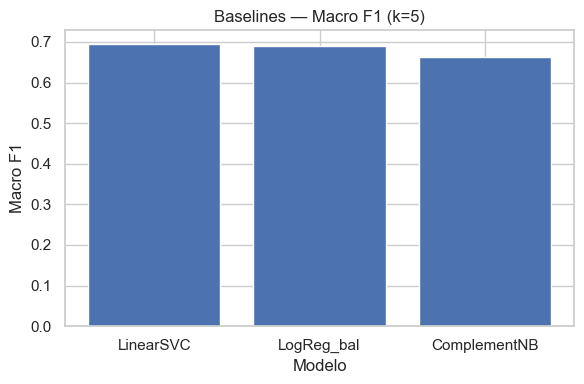

In [15]:
# CÉLULA 11B — Baselines comparativos

from sklearn.naive_bayes import ComplementNB

def eval_model(model, X, y, skf):
    accs, f1s = [], []
    for tr, te in skf.split(X, y):
        model.fit(X[tr], y[tr])
        yhat = model.predict(X[te])
        accs.append(accuracy_score(y[te], yhat))
        f1s.append(f1_score(y[te], yhat, average="macro"))
    return np.mean(accs), np.mean(f1s)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "LogReg_bal": LogisticRegression(max_iter=300, class_weight="balanced"),
    "LinearSVC": LinearSVC(),
    "ComplementNB": ComplementNB(),
}

scores = []
for name, mdl in models.items():
    acc, f1m = eval_model(mdl, X, y, skf)
    scores.append({"modelo": name, "kfold_acc": round(acc, 3), "kfold_macroF1": round(f1m, 3)})

score_df = pd.DataFrame(scores).sort_values("kfold_macroF1", ascending=False)
display(score_df)

score_df.to_csv(OUTDIR / "baseline_scoreboard.csv", index=False)
plt.figure(figsize=(6,4))
plt.bar(score_df["modelo"], score_df["kfold_macroF1"])
plt.title("Baselines — Macro F1 (k=5)")
plt.xlabel("Modelo"); plt.ylabel("Macro F1")
plt.tight_layout()
try: plt.savefig(OUTDIR / "baseline_scoreboard.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()


In [16]:
# CÉLULA 11C — Treinar & Salvar: LinearSVC “seco” + Calibrado (prob)

svc = LinearSVC()
svc.fit(X, y)
dump(svc, OUTDIR / "modelo_linear_svc.joblib")

try:
    cal_svc = CalibratedClassifierCV(estimator=LinearSVC(), method="sigmoid", cv=5)
except TypeError:
    cal_svc = CalibratedClassifierCV(base_estimator=LinearSVC(), method="sigmoid", cv=5)

cal_svc.fit(X, y)
dump(cal_svc, OUTDIR / "modelo_linear_svc_calibrado.joblib")

print("✓ Salvos:")
print(" -", OUTDIR / "modelo_linear_svc.joblib")
print(" -", OUTDIR / "modelo_linear_svc_calibrado.joblib")


✓ Salvos:
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\modelo_linear_svc.joblib
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\modelo_linear_svc_calibrado.joblib


<Figure size 800x600 with 0 Axes>

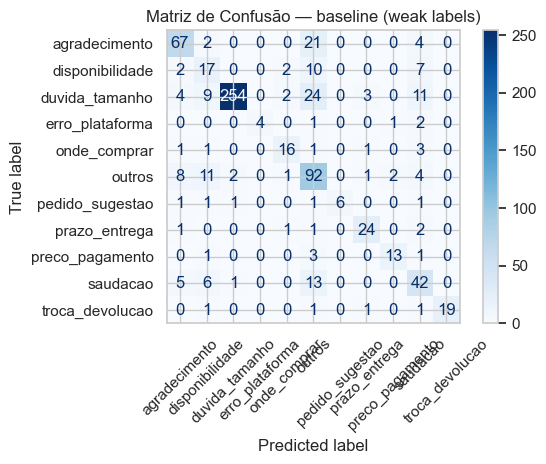

In [17]:
# CÉLULA 12 — Matriz de Confusão (agregada k-fold)

cm = confusion_matrix(y_true, y_pred, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", colorbar=True, xticks_rotation=45)
plt.title("Matriz de Confusão — baseline (weak labels)")
plt.tight_layout()
try: plt.savefig(OUTDIR / "matriz_confusao.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()


In [18]:
# CÉLULA 13 — Top termos por classe (coeficientes do modelo)

clf_full = LogisticRegression(max_iter=300, class_weight="balanced")
clf_full.fit(X, y)

feature_names = np.array(tfidf.get_feature_names_out())
n_top = 10
top_por_classe = {}

for i, cls in enumerate(le.classes_):
    coefs = clf_full.coef_[i]
    top_idx = np.argsort(coefs)[-n_top:][::-1]
    top_por_classe[cls] = feature_names[top_idx].tolist()

pd.DataFrame([{"intent": cls, "top_termos": ", ".join(terms)} for cls, terms in top_por_classe.items()])


,intent,top_termos
0,agradecimento,"presenca, presena, muito, retorno, acompanhar, mto, ok, perfeito, maravilhosa, prestigio"
1,disponibilidade,"loja, calca, gladiadora, whatsapp, compro, reposicao, preta, disponivel, cala, estoque"
2,duvida_tamanho,"verde, preto, tamanho, quero, blazer, vestido, saia, camisa, body, jaqueta"
3,erro_plataforma,"erro, senha, tamanhos, medidas, vem, dados cartao, tecnico, demora, tentei, sao"
4,onde_comprar,"whatsapp, numero, pode, nosso whatsapp, fatima, bem, falar, nao, este, whatsapp num"
5,outros,"coisa, linda, estilo, endereco, seguimos, modelagem, gentileza, tom, poderia passar, comprei jaqueta"
6,pedido_sugestao,"sugestao, look, looks, pecas, seus, seus looks, muito, ju, volumes, criar"
7,prazo_entrega,"frete, chega, entrega, valor frete, 022, valor, frete pro, num, rastreio, num dias"
8,preco_pagamento,"preco, faz, desconto, valor num, valor, quanto, cupom, cupom desconto, querer, pix"
9,saudacao,"bem, ola, vocaa, vai, oie, compras, td bem, direto, td, time"


In [19]:
# CÉLULA 14 — Superfície de Anotação (amostras mais incertas)

proba = clf_full.predict_proba(X)
pred = proba.argmax(axis=1)
margin = np.sort(proba, axis=1)[:, -1] - np.sort(proba, axis=1)[:, -2]

df_pool = df_ml.copy()
df_pool["pred_label"] = le.inverse_transform(pred)
df_pool["pred_prob"]  = proba.max(axis=1)
df_pool["margin"]     = margin

N_POR_CLASSE = 30
amostra = (df_pool.sort_values("margin")
                 .groupby("pred_label", group_keys=False)
                 .head(N_POR_CLASSE))

cols_export = ["ts", "autor", "texto", "origem", "label_regra", "pred_label", "pred_prob", "margin"]
amostra[cols_export].to_csv(OUTDIR / "amostra_para_anotacao.csv", index=False)
print("✓ Amostra p/ anotação:", OUTDIR / "amostra_para_anotacao.csv")
display(amostra[cols_export].head(12))


✓ Amostra p/ anotação: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\amostra_para_anotacao.csv


,ts,autor,texto,origem,label_regra,pred_label,pred_prob,margin
469,NaN,<NA>,oii karinne tudo bem aqui quem fala a c a ana do time curadobia vocaa acredita que estive olhando todos os dias desde que vocaa demonstrou interesse se a nossa saia anica voltaria ao estoque e som...,raw,disponibilidade,disponibilidade,0.276827,0.002080
538,NaN,<NA>,boa noite havera reposicao da saia unica preta no tamanho <num>,raw,duvida_tamanho,disponibilidade,0.210115,0.002183
629,NaN,<NA>,visto g qual tamanho seria quais cores tem tem a cala a tb,raw,duvida_tamanho,outros,0.156697,0.002293
558,NaN,<NA>,ola bom dia sou muito fa da bia mas nunca comprei no curadoria uma duvida como faco para escolher um tamanho com mais seguranca tem uma tabela de medidas para servir de referencia obrigada,raw,duvida_tamanho,agradecimento,0.137469,0.003278
684,NaN,<NA>,fui olhar para comprar o tamanho <num> dessa calca porem a largura da cintura e do quadril eh a mesma <num>,raw,duvida_tamanho,disponibilidade,0.183023,0.004718
710,NaN,<NA>,karyna bom dia tudo bem desculpe a demora para o esclarecimento da duvida como somos um marketolace trabalhamos com marcas unicas e diferentes como cada uma tem a sua producao optamos por entrar e...,raw,duvida_tamanho,duvida_tamanho,0.133181,0.004829
555,NaN,<NA>,oi talita muito bom receber sua mensagem agradecemos demais o contato e que bacana vocaas terem pensado na gente pora c m nesse momento na <num> s na o estamos trabalhando com produa a o de qualqu...,raw,duvida_tamanho,agradecimento,0.139997,0.007698
321,NaN,<NA>,tudo bem bia gostaria muito de saber se nesta sua plataforma vc assiste aos clientes em encontrar produtos lojas etc,raw,outros,outros,0.196348,0.008062
354,NaN,<NA>,essa sandalia calca certo calco <num> sera que preciso comprar <num>,raw,outros,outros,0.180549,0.009021
536,NaN,<NA>,oi bia tudo bem adorei a <user> o nome ficou demais e claro ja fui olhar as pecas nao localizei tabela de medidas porem pelo tamanho das pecas que vc veste o g provavelmente nao vai caber em mim u...,raw,duvida_tamanho,saudacao,0.135670,0.012176


In [20]:
# CÉLULA 15 — Export: dataset rotulado (weak) + artefatos

out_labels = df_cli.copy()
out_labels.to_csv(OUTDIR / "mensagens_rotuladas_fracas.csv", index=False)

dump(tfidf, OUTDIR / "vetorizer.joblib")
dump(clf_full, OUTDIR / "modelo_baseline.joblib")

print("✓ Export:")
print(" -", OUTDIR / "mensagens_rotuladas_fracas.csv")
print(" -", OUTDIR / "vetorizer.joblib")
print(" -", OUTDIR / "modelo_baseline.joblib")


✓ Export:
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\mensagens_rotuladas_fracas.csv
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\vetorizer.joblib
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\modelo_baseline.joblib


In [21]:
# CÉLULA 16 — Tabela estilizada: distribuição de intenções (weak)

dist = (df_cli["label_regra"]
        .value_counts()
        .rename_axis("intencao")
        .reset_index(name="qtd")
        .sort_values("qtd", ascending=False))
total = int(dist["qtd"].sum())
dist["%"] = (dist["qtd"] / total * 100).round(1)

sty = (dist.style
        .set_caption("Distribuição de intenções (rótulos fracos)")
        .format({"qtd": lambda v: f"{int(v):,}".replace(",", "."), "%": "{:.1f}%"})
        .set_properties(subset=pd.IndexSlice[:, ["intencao"]], **{"text-align": "left"})
        .set_properties(subset=pd.IndexSlice[:, ["qtd","%"]], **{"text-align": "right"})
        .set_table_styles([
            {"selector":"table","props":("border-collapse:separate;border-spacing:0;"
                                        "border:1px solid #CBD5E1; background:#FFFFFF; color:#111827;"
                                        "border-radius:6px; overflow:hidden;")},
            {"selector":"th","props":("background:#0F172A; color:#FFFFFF;"
                                      "font-weight:700; padding:10px 12px; text-align:left;")},
            {"selector":"td","props":("background:#FFFFFF; color:#111827;"
                                      "padding:10px 12px; border-top:1px solid #E5E7EB;")},
            {"selector":"tbody tr:nth-child(odd)","props":"background:#F8FAFC;"},
            {"selector":"caption","props":("caption-side:top; font-size:16px; margin:10px 0;"
                                           "font-weight:700; color:#111827;")},
        ]))

try:
    sty = sty.hide(axis="index")
except Exception:
    pass

display(sty)
(OUTDIR / "tabela_distribuicao_intencoes.html").write_text(sty.to_html(), encoding="utf-8")
print("✓ Tabela salva:", OUTDIR / "tabela_distribuicao_intencoes.html")


intencao,qtd,%
duvida_tamanho,307,41.2%
outros,121,16.2%
agradecimento,94,12.6%
saudacao,67,9.0%
disponibilidade,38,5.1%
prazo_entrega,29,3.9%
troca_devolucao,23,3.1%
onde_comprar,23,3.1%
preco_pagamento,18,2.4%
pedido_sugestao,11,1.5%


✓ Tabela salva: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\tabela_distribuicao_intencoes.html


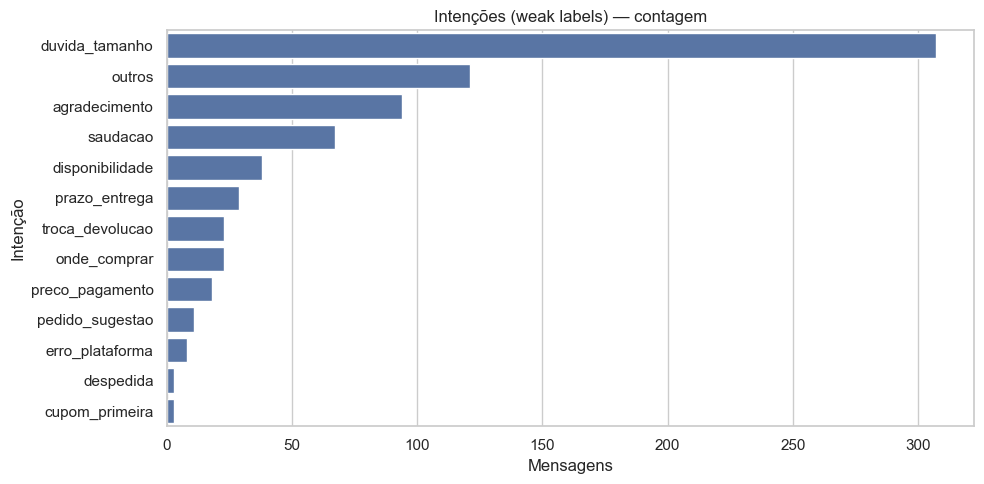

In [22]:
# CÉLULA 17 — Barplot das intenções (weak)

plt.figure(figsize=(10,5))
sns.barplot(data=dist, x="qtd", y="intencao")
plt.title("Intenções (weak labels) — contagem")
plt.xlabel("Mensagens"); plt.ylabel("Intenção")
plt.tight_layout()
try: plt.savefig(OUTDIR / "intencoes_barplot.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()


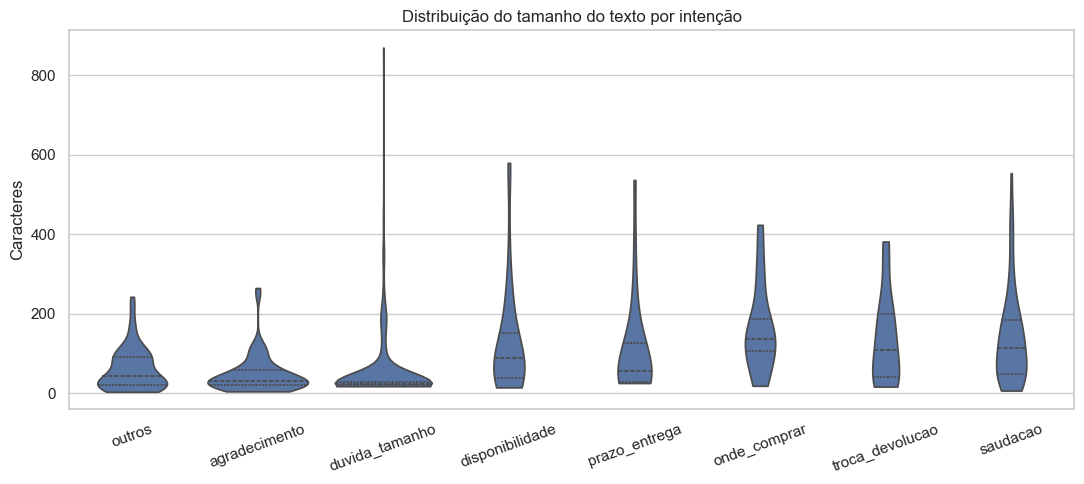

In [23]:
# CÉLULA 18 — Distribuição do tamanho do texto por intenção (top-8)

df_len = df_cli.copy()
df_len["n_chars"] = df_len["texto"].str.len()
top_classes = dist["intencao"].head(8).tolist()
df_len_top = df_len[df_len["label_regra"].isin(top_classes)]

plt.figure(figsize=(11,5))
sns.violinplot(data=df_len_top, x="label_regra", y="n_chars", inner="quartile", cut=0)
plt.xticks(rotation=20); plt.xlabel(""); plt.ylabel("Caracteres")
plt.title("Distribuição do tamanho do texto por intenção")
plt.tight_layout()
try: plt.savefig(OUTDIR / "tamanho_texto_por_intencao.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()


In [24]:
# CÉLULA 19 — Top termos por intenção (tabela + CSV/HTML)

top_df = pd.DataFrame(
    [{"intencao": cls, "top_termos": ", ".join(terms)} for cls, terms in top_por_classe.items()]
).sort_values("intencao")

sty2 = (top_df.style
        .set_caption("Top termos por intenção (coeficientes do modelo)")
        .set_properties(subset=pd.IndexSlice[:, ["intencao","top_termos"]], **{"text-align":"left"})
        .set_table_styles([
            {"selector":"table","props":("border-collapse:separate;border-spacing:0;"
                                        "border:1px solid #CBD5E1; background:#FFFFFF; color:#111827;"
                                        "border-radius:6px; overflow:hidden;")},
            {"selector":"th","props":("background:#0F172A; color:#FFFFFF;"
                                      "font-weight:700; padding:10px 12px; text-align:left;")},
            {"selector":"td","props":("background:#FFFFFF; color:#111827;"
                                      "padding:10px 12px; border-top:1px solid #E5E7EB;")},
            {"selector":"tbody tr:nth-child(odd)","props":"background:#F8FAFC;"},
            {"selector":"caption","props":("caption-side:top; font-size:16px; margin:10px 0;"
                                           "font-weight:700; color:#111827;")},
        ]))
try:
    sty2 = sty2.hide(axis="index")
except Exception:
    pass

display(sty2)
top_df.to_csv(OUTDIR / "top_termos_por_intencao.csv", index=False)
(OUTDIR / "top_termos_por_intencao.html").write_text(sty2.to_html(), encoding="utf-8")
print("✓ Salvos: top_termos_por_intencao.csv / top_termos_por_intencao.html")


intencao,top_termos
agradecimento,"presenca, presena, muito, retorno, acompanhar, mto, ok, perfeito, maravilhosa, prestigio"
disponibilidade,"loja, calca, gladiadora, whatsapp, compro, reposicao, preta, disponivel, cala, estoque"
duvida_tamanho,"verde, preto, tamanho, quero, blazer, vestido, saia, camisa, body, jaqueta"
erro_plataforma,"erro, senha, tamanhos, medidas, vem, dados cartao, tecnico, demora, tentei, sao"
onde_comprar,"whatsapp, numero, pode, nosso whatsapp, fatima, bem, falar, nao, este, whatsapp num"
outros,"coisa, linda, estilo, endereco, seguimos, modelagem, gentileza, tom, poderia passar, comprei jaqueta"
pedido_sugestao,"sugestao, look, looks, pecas, seus, seus looks, muito, ju, volumes, criar"
prazo_entrega,"frete, chega, entrega, valor frete, 022, valor, frete pro, num, rastreio, num dias"
preco_pagamento,"preco, faz, desconto, valor num, valor, quanto, cupom, cupom desconto, querer, pix"
saudacao,"bem, ola, vocaa, vai, oie, compras, td bem, direto, td, time"


✓ Salvos: top_termos_por_intencao.csv / top_termos_por_intencao.html


In [25]:
# CÉLULA 20 — Série mensal (Top-5 intenções)

df_time = df_cli.copy()
df_time["ts"] = pd.to_datetime(df_time["ts"], errors="coerce")
df_time = df_time.dropna(subset=["ts"])
df_time["mes"] = df_time["ts"].dt.to_period("M").dt.to_timestamp()

top5 = dist["intencao"].head(5).tolist()
sub = df_time[df_time["label_regra"].isin(top5)]

if not sub.empty:
    grp = (sub.groupby(["mes","label_regra"])["texto"].count().rename("qtd").reset_index())
    plt.figure(figsize=(12,4))
    for intent, g in grp.groupby("label_regra"):
        g = g.sort_values("mes")
        plt.plot(g["mes"], g["qtd"], marker="o", label=intent)
    plt.title("Série mensal — Top-5 intenções (weak labels)")
    plt.xlabel("Mês"); plt.ylabel("Mensagens"); plt.legend(title="Intenção", ncol=2)
    plt.tight_layout()
    try: plt.savefig(OUTDIR / "serie_mensal_top5_intencoes.png", dpi=150, bbox_inches="tight")
    except: pass
    plt.show()
else:
    print("Sem timestamps válidos para série mensal.")


Sem timestamps válidos para série mensal.


Cobertura (mensagens com intenção reconhecida): 624/745 (83.8%)


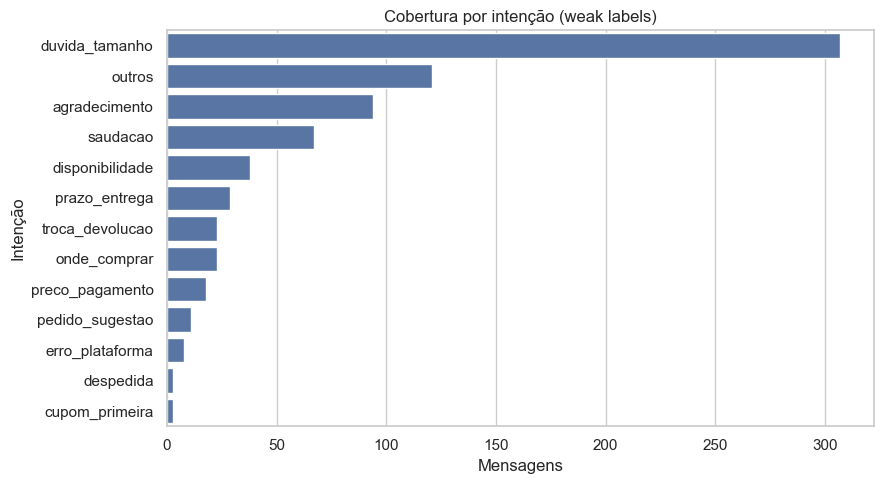

,intencao,qtd,% do total
0,duvida_tamanho,307,41.2
1,outros,121,16.2
2,agradecimento,94,12.6
3,saudacao,67,9.0
4,disponibilidade,38,5.1
5,prazo_entrega,29,3.9
6,troca_devolucao,23,3.1
7,onde_comprar,23,3.1
8,preco_pagamento,18,2.4
9,pedido_sugestao,11,1.5


In [27]:
# CÉLULA 21 — Cobertura por intenção (≠ 'outros')

tot = len(df_cli)
dist_cov = df_cli["label_regra"].value_counts().rename_axis("intencao").reset_index(name="qtd")
dist_cov["%_total"] = (dist_cov["qtd"]/tot*100).round(1)

cov = dist_cov.copy()
cov["coberta"] = cov["intencao"] != "outros"
cobertas = cov[cov["coberta"]]["qtd"].sum()
print(f"Cobertura (mensagens com intenção reconhecida): {cobertas}/{tot} ({cobertas/tot:.1%})")

plt.figure(figsize=(9,5))
sns.barplot(data=dist_cov.sort_values("qtd", ascending=False), x="qtd", y="intencao")
plt.title("Cobertura por intenção (weak labels)")
plt.xlabel("Mensagens"); plt.ylabel("Intenção")
plt.tight_layout()
try: plt.savefig(OUTDIR / "cobertura_por_intencao.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()

dist_style = dist_cov.copy()
dist_style.columns = ["intencao","qtd","% do total"]
display(dist_style)


In [28]:
# CÉLULA 22 — Top confusões (pares real × predito)

cm = confusion_matrix(y_true, y_pred, labels=range(len(le.classes_)))
labels = list(le.classes_)
pairs = []
for i, real in enumerate(labels):
    for j, pred in enumerate(labels):
        if i != j and cm[i, j] > 0:
            pairs.append((real, pred, int(cm[i, j])))

conf_df = pd.DataFrame(pairs, columns=["real","predito","qtd"]).sort_values("qtd", ascending=False)
display(conf_df.head(10))
conf_df.to_csv(OUTDIR / "top_confusoes.csv", index=False)
print("✓ Top confusões salvas:", OUTDIR / "top_confusoes.csv")


,real,predito,qtd
10,duvida_tamanho,outros,24
1,agradecimento,outros,21
43,saudacao,outros,13
12,duvida_tamanho,saudacao,11
22,outros,disponibilidade,11
5,disponibilidade,outros,10
8,duvida_tamanho,disponibilidade,9
21,outros,agradecimento,8
6,disponibilidade,saudacao,7
41,saudacao,disponibilidade,6


✓ Top confusões salvas: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\top_confusoes.csv


In [29]:
# CÉLULA 23 — N-grams em 'outros' (para futuras regras)

def _clean_for_ngrams(s: str) -> str:
    s = normalize_text(s).lower()
    s = re.sub(r"http\S+|www\.\S+"," ", s)
    s = re.sub(r"[@#]\w+"," ", s)
    s = re.sub(r"[^\w\sáéíóúâêôãõç]"," ", s)
    return re.sub(r"\s+"," ", s).strip()

outros_texts = df_cli[df_cli["label_regra"]=="outros"]["texto"].astype(str).map(_clean_for_ngrams).tolist()
vec_outros = CountVectorizer(ngram_range=(1,2), min_df=3)
X_outros = vec_outros.fit_transform([t for t in outros_texts if t])

fr = np.asarray(X_outros.sum(axis=0)).ravel()
trs = np.array(vec_outros.get_feature_names_out())
idx = np.argsort(fr)[::-1][:30]
out_top = pd.DataFrame({"ngram": trs[idx], "freq": fr[idx]})

display(out_top.head(30))
out_top.to_csv(OUTDIR / "ngram_outros.csv", index=False)
print("✓ n-grams de 'outros' salvos:", OUTDIR / "ngram_outros.csv")


,ngram,freq
0,que,43
1,de,33
2,site,20
3,da,19
4,no,19
5,com,19
6,mas,18
7,por,16
8,num,16
9,na,16


✓ n-grams de 'outros' salvos: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\ngram_outros.csv


In [30]:
# CÉLULA 24 — Gating por confiança (LogReg)

thr = 0.55
df_pred = df_ml.copy()
X_pred = tfidf.transform(df_ml["texto_ml"])

pred_proba = clf_full.predict_proba(X_pred)
pred_idx   = pred_proba.argmax(axis=1)

df_pred["pred_label"] = le.inverse_transform(pred_idx)
df_pred["pred_prob"]  = pred_proba.max(axis=1)
df_pred["aceita"]     = df_pred["pred_prob"] >= thr

print("Aceitas (LogReg, ≥ {:.2f}): {} / {} ({:.1%})".format(thr, int(df_pred["aceita"].sum()), len(df_pred), df_pred["aceita"].mean()))
cols = ["ts", "autor", "texto", "origem", "label_regra", "pred_label", "pred_prob"]
display(df_pred[df_pred["aceita"]][cols].head(10))

df_pred[df_pred["aceita"]][cols].to_csv(OUTDIR / "predicoes_confianca_ge_055.csv", index=False)
print("✓ Predições (LogReg) salvas:", OUTDIR / "predicoes_confianca_ge_055.csv")


Aceitas (LogReg, ≥ 0.55): 308 / 739 (41.7%)


,ts,autor,texto,origem,label_regra,pred_label,pred_prob
3,NaN,<NA>,tem body preto tamanho 40?,synthetic,duvida_tamanho,duvida_tamanho,0.773786
4,NaN,<NA>,tem vestido verde tamanho 38?,synthetic,duvida_tamanho,duvida_tamanho,0.772387
5,NaN,<NA>,tem blazer verde tamanho 42?,synthetic,duvida_tamanho,duvida_tamanho,0.781154
6,NaN,<NA>,tem jaqueta preto tamanho 40?,synthetic,duvida_tamanho,duvida_tamanho,0.743911
7,NaN,<NA>,tem body preto tamanho 46?,raw,duvida_tamanho,duvida_tamanho,0.773786
8,NaN,<NA>,quero vestido verde 44,raw,duvida_tamanho,duvida_tamanho,0.681844
9,NaN,<NA>,tem camisa preto tamanho 42?,raw,duvida_tamanho,duvida_tamanho,0.777260
10,NaN,<NA>,quero vestido verde 42,raw,duvida_tamanho,duvida_tamanho,0.681844
11,NaN,<NA>,tem body verde tamanho P?,raw,duvida_tamanho,duvida_tamanho,0.784123
12,NaN,<NA>,tem body verde tamanho 40?,raw,duvida_tamanho,duvida_tamanho,0.784123


✓ Predições (LogReg) salvas: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\predicoes_confianca_ge_055.csv


In [31]:
# CÉLULA 25 — Gating por confiança (LinearSVC calibrado)

thr = 0.55
df_pred_cal = df_ml.copy()
X_pred_cal = tfidf.transform(df_ml["texto_ml"])

try:
    cal_svc_loaded = cal_svc
except NameError:
    cal_svc_loaded = load(OUTDIR / "modelo_linear_svc_calibrado.joblib")

proba_cal   = cal_svc_loaded.predict_proba(X_pred_cal)
pred_idx_ca = proba_cal.argmax(axis=1)

df_pred_cal["pred_label"] = le.inverse_transform(pred_idx_ca)
df_pred_cal["pred_prob"]  = proba_cal.max(axis=1)
df_pred_cal["aceita"]     = df_pred_cal["pred_prob"] >= thr

print("Aceitas (SVC calibrado, ≥ {:.2f}): {} / {} ({:.1%})".format(thr, int(df_pred_cal["aceita"].sum()), len(df_pred_cal), df_pred_cal["aceita"].mean()))
cols = ["ts", "autor", "texto", "origem", "label_regra", "pred_label", "pred_prob"]
display(df_pred_cal[df_pred_cal["aceita"]][cols].head(10))

df_pred_cal[df_pred_cal["aceita"]][cols].to_csv(OUTDIR / "predicoes_svc_calibrado_ge_055.csv", index=False)
print("✓ Predições (SVC calibrado) salvas:", OUTDIR / "predicoes_svc_calibrado_ge_055.csv")


Aceitas (SVC calibrado, ≥ 0.55): 680 / 739 (92.0%)


,ts,autor,texto,origem,label_regra,pred_label,pred_prob
0,NaN,<NA>,de todo modo agradeco por perguntar,raw,outros,outros,0.698658
1,NaN,<NA>,agradeco o feedback,raw,outros,outros,0.653475
3,NaN,<NA>,tem body preto tamanho 40?,synthetic,duvida_tamanho,duvida_tamanho,0.877504
4,NaN,<NA>,tem vestido verde tamanho 38?,synthetic,duvida_tamanho,duvida_tamanho,0.876015
5,NaN,<NA>,tem blazer verde tamanho 42?,synthetic,duvida_tamanho,duvida_tamanho,0.877159
6,NaN,<NA>,tem jaqueta preto tamanho 40?,synthetic,duvida_tamanho,duvida_tamanho,0.872286
7,NaN,<NA>,tem body preto tamanho 46?,raw,duvida_tamanho,duvida_tamanho,0.877504
8,NaN,<NA>,quero vestido verde 44,raw,duvida_tamanho,duvida_tamanho,0.838750
9,NaN,<NA>,tem camisa preto tamanho 42?,raw,duvida_tamanho,duvida_tamanho,0.870971
10,NaN,<NA>,quero vestido verde 42,raw,duvida_tamanho,duvida_tamanho,0.838750


✓ Predições (SVC calibrado) salvas: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook02\predicoes_svc_calibrado_ge_055.csv


In [32]:
# CÉLULA 26 — Checklist dos arquivos gerados

import datetime as dt
rows = []
for p in sorted(OUTDIR.glob("*")):
    if p.is_file():
        mtime = dt.datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
        size_kb = f"{p.stat().st_size/1024:.1f} KB"
        rows.append([p.name, mtime, size_kb])

chk = pd.DataFrame(rows, columns=["arquivo","modificado","tamanho"]).sort_values("arquivo")
display(chk)


,arquivo,modificado,tamanho
0,amostra_para_anotacao.csv,2025-09-23 19:42,50.0 KB
1,baseline_scoreboard.csv,2025-09-23 19:42,0.1 KB
2,baseline_scoreboard.png,2025-09-23 19:42,30.4 KB
3,cobertura_por_intencao.png,2025-09-23 19:44,69.7 KB
4,intencoes_barplot.png,2025-09-23 19:43,70.7 KB
5,matriz_confusao.png,2025-09-23 19:42,154.6 KB
6,mensagens_rotuladas_fracas.csv,2025-09-23 19:43,347.6 KB
7,modelo_baseline.joblib,2025-09-23 19:43,151.7 KB
8,modelo_linear_svc.joblib,2025-09-23 19:42,151.5 KB
9,modelo_linear_svc_calibrado.joblib,2025-09-23 19:42,760.1 KB


In [33]:
# CÉLULA 27 — Sanity local do modelo calibrado (5 amostras)

mdl_path = OUTDIR / "modelo_linear_svc_calibrado.joblib"
vec_path = OUTDIR / "vetorizer.joblib"
data_path = OUTDIR / "mensagens_rotuladas_fracas.csv"

print("Sklearn versão:", __import__("sklearn").__version__)

cal = load(mdl_path)
vec = load(vec_path)

df_all = pd.read_csv(data_path)
df_cli_val = df_all[df_all["lado"].eq("cliente")].copy()
df_cli_val["texto_ml"] = df_cli_val["texto"].astype(str)

X_sample = vec.transform(df_cli_val["texto_ml"].head(5))
proba = cal.predict_proba(X_sample)
pred = proba.argmax(axis=1)
classes = cal.classes_

for i, (pidx, probs) in enumerate(zip(pred, proba)):
    print(f"{i:02d} → {classes[pidx]} | conf={probs.max():.3f}")


Sklearn versão: 1.7.2
00 → 5 | conf=0.699
01 → 5 | conf=0.653
02 → 5 | conf=0.434
03 → 2 | conf=0.878
04 → 2 | conf=0.876
